# 01 — Exploratory Data Analysis
*German Credit Risk Dataset — UCI Statlog Encoding*

---

## 1. Data Loading & Initial Inspection

The dataset is sourced directly from the UCI ML Repository. It contains **1,000 loan applicants** 
described by **20 features** and a binary target (`credit_risk`). All features arrive in raw 
Statlog encoding — categorical columns use codes like `A11`, `A34` which will be decoded in 
Section 2.

### Feature Dictionary

| Feature | Type | Description |
|---|---|---|
| status | Categorical | Checking account status |
| duration | Numeric | Loan duration in months |
| credit_history | Categorical | Past credit behaviour |
| purpose | Categorical | Reason for the loan |
| amount | Numeric | Loan amount in DM |
| savings | Categorical | Savings account balance |
| employment_duration | Categorical | Years at current employer |
| installment_rate | Numeric | Repayment rate as % of income (1–4 scale) |
| personal_status_sex | Categorical | Gender and marital status combined |
| other_debtors | Categorical | Guarantors or co-applicants |
| present_residence | Numeric | Years at current address (1–4 scale) |
| property | Categorical | Most valuable owned property |
| age | Numeric | Applicant age in years |
| other_installment_plans | Categorical | Other active credit plans |
| housing | Categorical | Housing situation |
| number_credits | Numeric | Number of existing credits at this bank |
| job | Categorical | Employment skill level |
| people_liable | Numeric | Number of dependants |
| telephone | Categorical | Registered phone (yes/no) |
| foreign_worker | Categorical | Foreign worker status (yes/no) |
| credit_risk | Target | 0 = Good, 1 = Bad (after decoding) |

In [ ]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

col_names = [
    "status", "duration", "credit_history", "purpose", "amount",
    "savings", "employment_duration", "installment_rate", "personal_status_sex",
    "other_debtors", "present_residence", "property", "age",
    "other_installment_plans", "housing", "number_credits", "job",
    "people_liable", "telephone", "foreign_worker", "credit_risk"
]

df = pd.read_csv(url, sep=" ", header=None, names=col_names)

print("Shape:", df.shape)
print("\nTarget value counts:")
print(df["credit_risk"].value_counts())
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1000, 21)

Target value counts:
credit_risk
1    700
2    300
Name: count, dtype: int64

Column names:
['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'credit_risk']

First 5 rows:


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


### Findings — Shape & Class Balance

- Dataset has **1,000 rows and 21 columns** (20 features + 1 target)
- Target distribution: **700 good (70%) vs 300 bad (30%)** — moderately imbalanced
- This imbalance matters: a naive model that predicts "good" for everyone would achieve 
  70% accuracy without learning anything. We will address this during modelling.
- Note: target shows as `1` and `2` here (raw Statlog). This gets binarized to `0` and `1` 
  after decoding.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

### Findings — Data Types & Missing Values

- **No missing values** across all 1,000 rows — the dataset is complete, no imputation required
- **8 numeric columns** (`int64`): duration, amount, installment_rate, present_residence, 
  age, number_credits, people_liable, credit_risk
- **13 categorical columns** (`object`): all remaining features in raw Statlog encoding
- Note: `installment_rate` and `present_residence` are numeric here but are actually 
  **ordinal scales (1–4)**, not continuous measurements

In [4]:
df.describe()

,duration,amount,installment_rate,present_residence,age,number_credits,people_liable,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


### Findings — Descriptive Statistics

| Observation | Detail |
|---|---|
| `amount` | Wide range (250–18,424 DM), std of 2,822 — highly skewed, likely outliers |
| `duration` | 4–72 months, median 18 — most loans are short-to-medium term |
| `age` | 19–75 years, mean ~35 — skewed toward younger applicants |
| `installment_rate` | Ordinal 1–4 scale, median 3 |
| `number_credits` | Mostly 1–2, max 4 — few applicants have many credits |
| `people_liable` | Mostly 1, max 2 — low number of dependants across the board |

---

## 2. Feature Decoding

The raw Statlog encoding uses codes like `A11`, `A34` which are meaningless without the UCI 
data dictionary. We decode all categorical columns using the official mappings from `german.doc`, 
and binarize the target: `1 (good) → 0`, `2 (bad) → 1`.

After decoding, `df_decoded` is the working dataframe for all remaining analysis.

In [5]:
# Decode Statlog categorical columns
status_map = {
    'A11': '< 0 DM', 'A12': '0–200 DM', 'A13': '>= 200 DM', 'A14': 'no account'
}
credit_history_map = {
    'A30': 'no credits', 'A31': 'all paid', 'A32': 'existing paid',
    'A33': 'delay in past', 'A34': 'critical account'
}
purpose_map = {
    'A40': 'car (new)', 'A41': 'car (used)', 'A42': 'furniture', 'A43': 'TV/radio',
    'A44': 'appliances', 'A45': 'repairs', 'A46': 'education', 'A47': 'vacation',
    'A48': 'retraining', 'A49': 'business', 'A410': 'other'
}
savings_map = {
    'A61': '< 100 DM', 'A62': '100–500 DM', 'A63': '500–1000 DM',
    'A64': '>= 1000 DM', 'A65': 'unknown/none'
}
employment_map = {
    'A71': 'unemployed', 'A72': '< 1 yr', 'A73': '1–4 yrs',
    'A74': '4–7 yrs', 'A75': '>= 7 yrs'
}
personal_status_map = {
    'A91': 'male divorced', 'A92': 'female divorced/married',
    'A93': 'male single', 'A94': 'male married', 'A95': 'female single'
}
other_debtors_map = {'A101': 'none', 'A102': 'co-applicant', 'A103': 'guarantor'}
property_map = {
    'A121': 'real estate', 'A122': 'savings/insurance',
    'A123': 'car/other', 'A124': 'unknown/none'
}
other_installment_map = {'A141': 'bank', 'A142': 'stores', 'A143': 'none'}
housing_map = {'A151': 'rent', 'A152': 'own', 'A153': 'free'}
job_map = {
    'A171': 'unskilled non-resident', 'A172': 'unskilled resident',
    'A173': 'skilled', 'A174': 'highly skilled'
}
telephone_map = {'A191': 'none', 'A192': 'yes'}
foreign_worker_map = {'A201': 'yes', 'A202': 'no'}

df_decoded = df.copy()
df_decoded['status'] = df['status'].map(status_map)
df_decoded['credit_history'] = df['credit_history'].map(credit_history_map)
df_decoded['purpose'] = df['purpose'].map(purpose_map)
df_decoded['savings'] = df['savings'].map(savings_map)
df_decoded['employment_duration'] = df['employment_duration'].map(employment_map)
df_decoded['personal_status_sex'] = df['personal_status_sex'].map(personal_status_map)
df_decoded['other_debtors'] = df['other_debtors'].map(other_debtors_map)
df_decoded['property'] = df['property'].map(property_map)
df_decoded['other_installment_plans'] = df['other_installment_plans'].map(other_installment_map)
df_decoded['housing'] = df['housing'].map(housing_map)
df_decoded['job'] = df['job'].map(job_map)
df_decoded['telephone'] = df['telephone'].map(telephone_map)
df_decoded['foreign_worker'] = df['foreign_worker'].map(foreign_worker_map)

# Make target binary: 0 = good, 1 = bad
df_decoded['credit_risk'] = df['credit_risk'].map({1: 0, 2: 1})

df_decoded.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,< 0 DM,6,critical account,TV/radio,1169,unknown/none,>= 7 yrs,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,0
1,0–200 DM,48,existing paid,TV/radio,5951,< 100 DM,1–4 yrs,2,female divorced/married,none,...,real estate,22,none,own,1,skilled,1,none,yes,1
2,no account,12,critical account,education,2096,< 100 DM,4–7 yrs,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,0
3,< 0 DM,42,existing paid,furniture,7882,< 100 DM,4–7 yrs,2,male single,guarantor,...,savings/insurance,45,none,free,1,skilled,2,none,yes,0
4,< 0 DM,24,delay in past,car (new),4870,< 100 DM,1–4 yrs,3,male single,none,...,unknown/none,53,none,free,2,skilled,2,none,yes,1


---

## 3. Univariate & Bivariate Distributions

We examine the distribution of key numeric features and how categorical features split 
across credit risk classes.

/var/folders/_2/4xkg4dyd1zd06jf_5_zjz98h0000gn/T/ipykernel_82728/284418281.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(['Good (0)', 'Bad (1)'])


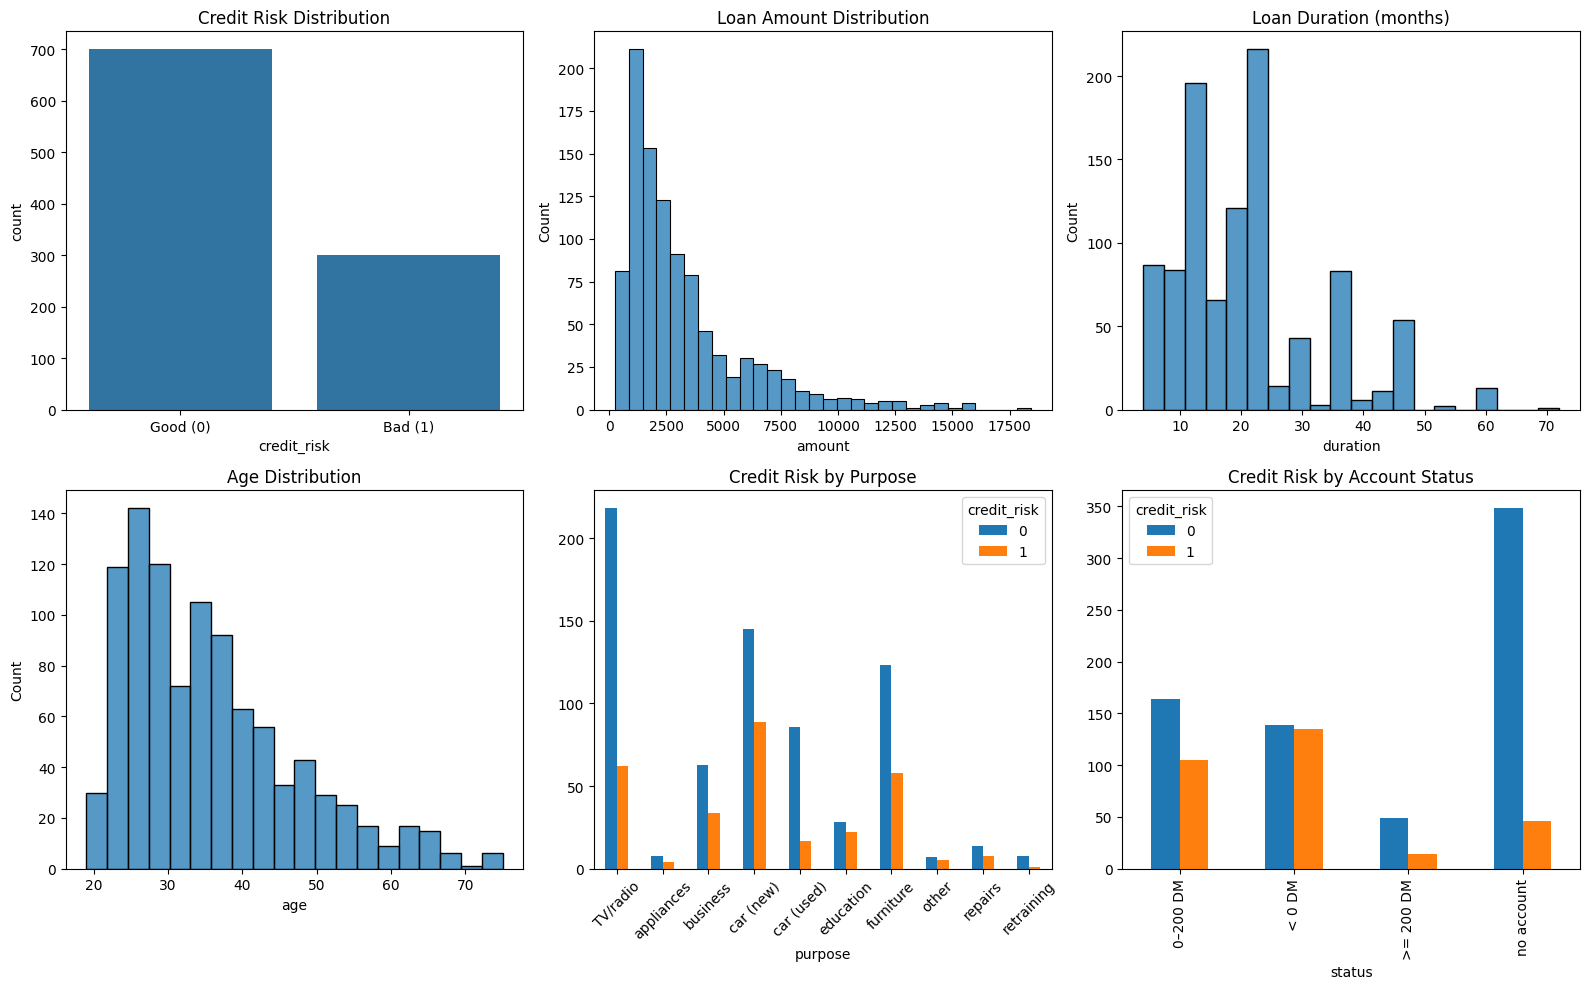

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Target distribution
sns.countplot(x='credit_risk', data=df_decoded, ax=axes[0,0])
axes[0,0].set_title('Credit Risk Distribution')
axes[0,0].set_xticklabels(['Good (0)', 'Bad (1)'])

# 2. Loan amount distribution
sns.histplot(df_decoded['amount'], bins=30, ax=axes[0,1])
axes[0,1].set_title('Loan Amount Distribution')

# 3. Duration distribution
sns.histplot(df_decoded['duration'], bins=20, ax=axes[0,2])
axes[0,2].set_title('Loan Duration (months)')

# 4. Age distribution
sns.histplot(df_decoded['age'], bins=20, ax=axes[1,0])
axes[1,0].set_title('Age Distribution')

# 5. Credit risk by purpose
purpose_counts = df_decoded.groupby(['purpose', 'credit_risk']).size().unstack()
purpose_counts.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Credit Risk by Purpose')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Credit risk by status (checking account)
status_counts = df_decoded.groupby(['status', 'credit_risk']).size().unstack()
status_counts.plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Credit Risk by Account Status')

plt.tight_layout()
plt.show()

### Findings — Distribution Plots

**Credit Risk Distribution**
- 700 good (70%) vs 300 bad (30%) — class imbalance confirmed visually
- A model trained without addressing this will be biased toward predicting "good"

**Loan Amount**
- Strongly right-skewed — most loans are below 2,500 DM but a long tail extends to ~18,000 DM
- The mean (3,271 DM) is pulled up by large outliers; the median (2,320 DM) is more representative
- This skew means `amount` will need scaling before modelling

**Loan Duration**
- Peaks at 12–24 months, right-skewed
- Most borrowers take short-to-medium term loans; very few exceed 48 months

**Age**
- Right-skewed, peaks around 25–30, thins out after 50
- The dataset skews young — older applicants are underrepresented

**Credit Risk by Purpose**
- TV/radio is the most common loan purpose by a wide margin
- Car (new) and furniture show a noticeably higher bad-credit ratio relative to their volume
- Retraining and other categories have very few observations — low statistical reliability

**Credit Risk by Account Status**
- Applicants with no checking account show almost no bad credit cases
- Applicants with negative balances (< 0 DM) have a disproportionately high bad-credit rate
- This aligns with intuition: existing financial stress predicts future default



---

## 4. Correlation Analysis (Numeric Features)

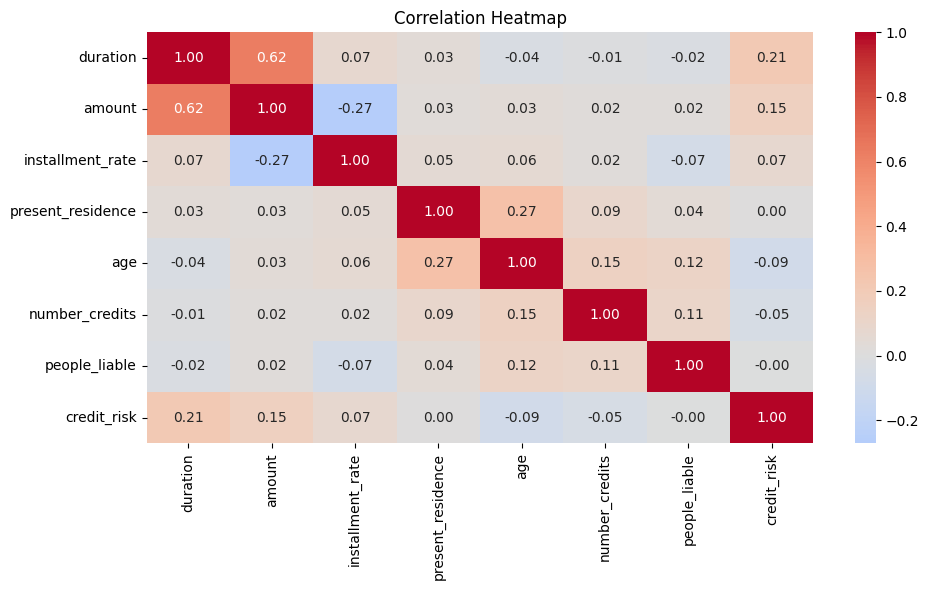

In [7]:
# Correlation heatmap (numeric columns only)
plt.figure(figsize=(10, 6))
sns.heatmap(
    df_decoded.select_dtypes(include='number').corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Findings — Correlation Heatmap

The heatmap shows Pearson correlations between numeric features only. It is used here to detect multicollinearity between features (categorical features carry most of the predictive signal, as shown in Section 5).

| Pair | Correlation | Interpretation |
|---|---|---|
| `duration` ↔ `amount` | 0.62 | Larger loans tend to have longer repayment periods |
| `age` ↔ `present_residence` | 0.27 | Older applicants tend to have lived longer at their address |
| `amount` ↔ `installment_rate` | -0.27 | Larger loans tend to carry lower installment rates |
| `duration` ↔ `credit_risk` | 0.21 | Longer loans weakly associated with higher risk |
| `amount` ↔ `credit_risk` | 0.15 | Larger loans weakly associated with higher risk |

**Key takeaway:** No single numeric feature strongly predicts credit risk on its own. 
The `duration`–`amount` correlation (0.62) is worth monitoring for multicollinearity 
in linear models, though it is not severe enough to require dropping either feature.



## 5. Categorical Feature Significance (Chi-Square Test)

We test each categorical feature against `credit_risk` using the chi-square test of independence. 
A p-value below 0.05 indicates the feature has a statistically significant relationship with 
credit risk.

In [8]:
from scipy.stats import chi2_contingency

cat_cols = ['status', 'credit_history', 'purpose', 'savings', 
            'employment_duration', 'personal_status_sex', 'other_debtors',
            'property', 'other_installment_plans', 'housing', 
            'job', 'telephone', 'foreign_worker']

results = []
for col in cat_cols:
    ct = pd.crosstab(df_decoded[col], df_decoded['credit_risk'])
    chi2, p, dof, _ = chi2_contingency(ct)
    results.append({'feature': col, 'chi2': round(chi2, 2), 'p_value': round(p, 4)})

chi_df = pd.DataFrame(results).sort_values('chi2', ascending=False)
print(chi_df.to_string(index=False))

                feature   chi2  p_value
                 status 123.72   0.0000
         credit_history  61.69   0.0000
                savings  36.10   0.0000
                purpose  33.36   0.0001
               property  23.72   0.0000
    employment_duration  18.37   0.0010
                housing  18.20   0.0001
other_installment_plans  12.84   0.0016
    personal_status_sex   9.61   0.0222
          other_debtors   6.65   0.0361
         foreign_worker   5.82   0.0158
                    job   1.89   0.5966
              telephone   1.17   0.2789


### Findings

| Tier | Features | Interpretation |
|---|---|---|
| **Strong** (chi2 > 30) | `status`, `credit_history`, `savings`, `purpose`, `property` | High predictive signal — prioritise in modelling |
| **Moderate** (chi2 10–30) | `employment_duration`, `housing`, `other_installment_plans`, `personal_status_sex`, `other_debtors` | Meaningful but weaker signal |
| **Weak but significant** (chi2 < 10, p < 0.05) | `foreign_worker` | Low chi2 but still significant — retain for now |
| **Insignificant** (p > 0.05) | `job`, `telephone` | No significant relationship with credit risk — candidates for dropping |

**Key takeaway:** `status` (checking account balance) is the single strongest predictor
in the dataset (chi2 = 123.72). `job` and `telephone` are the only features showing no
significant relationship with credit risk and are candidates for dropping during feature selection.

## Outlier Analysis

Boxplots are used to detect outliers in each numeric feature. The whiskers extend to 1.5× IQR; points beyond that are plotted individually as potential outliers.

Columns checked: `duration`, `amount`, `installment_rate`, `present_residence`, `age`, `number_credits`, `people_liable`.

Note that IQR-based flagging can mislead on low-cardinality or ordinal columns — context
matters when deciding whether to act on outliers.

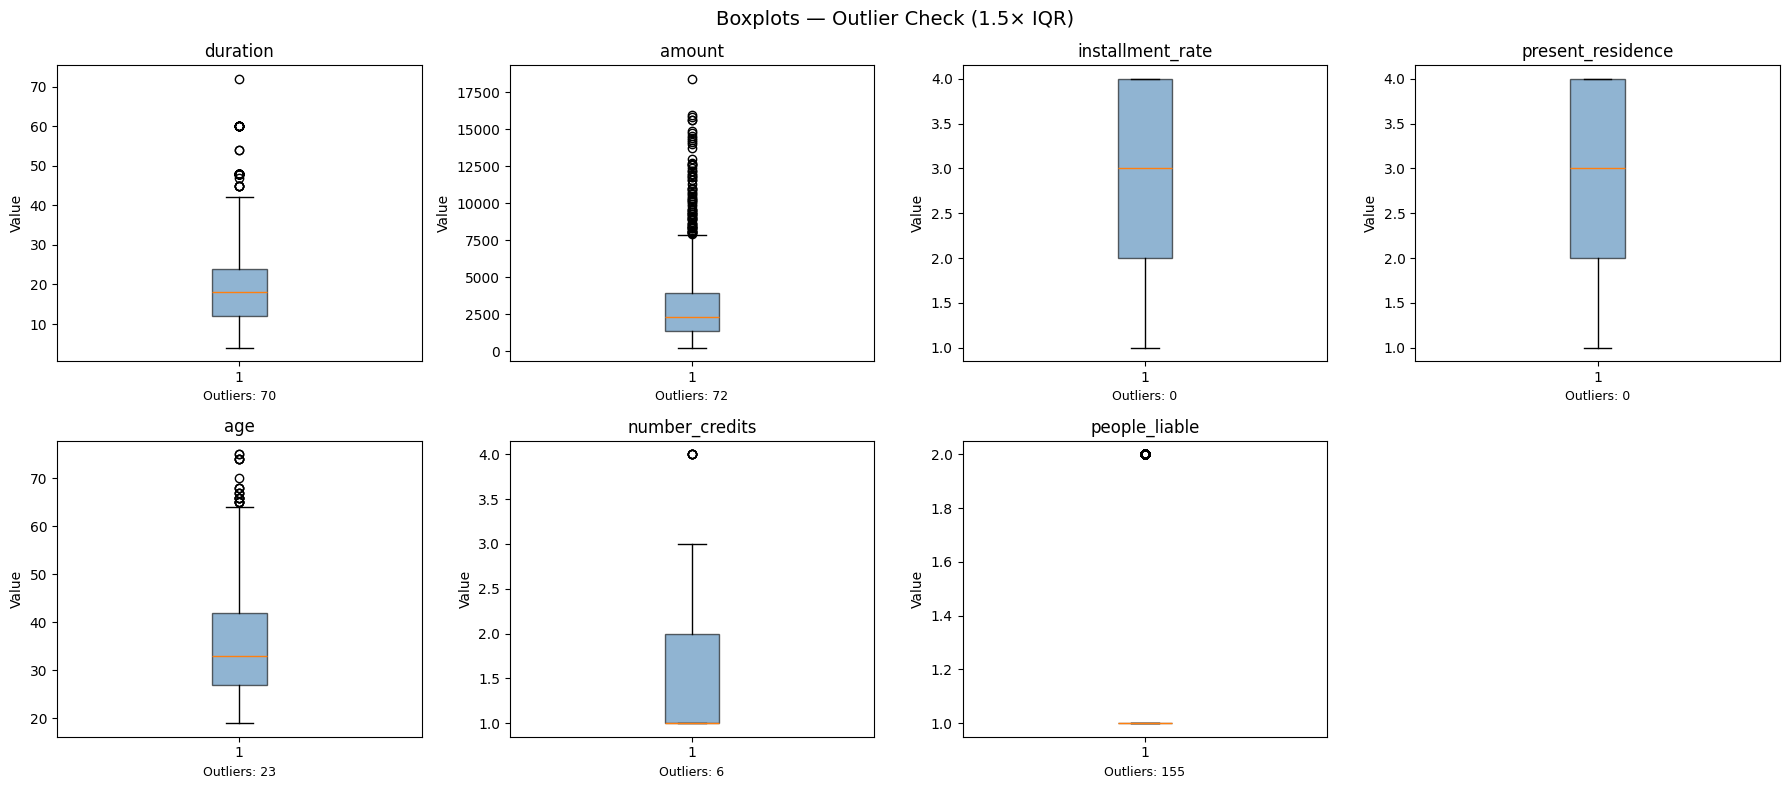

Column                     Min      Q1   Median      Q3      Max  Outliers
------------------------------------------------------------------------
duration                   4.0    12.0     18.0    24.0     72.0        70
amount                   250.0  1365.5   2319.5  3972.2  18424.0        72
installment_rate           1.0     2.0      3.0     4.0      4.0         0
present_residence          1.0     2.0      3.0     4.0      4.0         0
age                       19.0    27.0     33.0    42.0     75.0        23
number_credits             1.0     1.0      1.0     2.0      4.0         6
people_liable              1.0     1.0      1.0     1.0      2.0       155


In [9]:
numeric_cols = ['duration', 'amount', 'installment_rate', 'present_residence',
                'age', 'number_credits', 'people_liable']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_decoded[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

    Q1 = df_decoded[col].quantile(0.25)
    Q3 = df_decoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_decoded[col] < lower) | (df_decoded[col] > upper)).sum()
    axes[i].set_xlabel(f'Outliers: {n_out}', fontsize=9)

# hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Boxplots — Outlier Check (1.5× IQR)', fontsize=14)
plt.tight_layout()
plt.show()

# Print IQR summary table
print(f"{'Column':<22} {'Min':>7} {'Q1':>7} {'Median':>8} {'Q3':>7} {'Max':>8} {'Outliers':>9}")
print("-" * 72)
for col in numeric_cols:
    Q1 = df_decoded[col].quantile(0.25)
    Q3 = df_decoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_decoded[col] < lower) | (df_decoded[col] > upper)).sum()
    print(f"{col:<22} {df_decoded[col].min():>7.1f} {Q1:>7.1f} {df_decoded[col].median():>8.1f} "
          f"{Q3:>7.1f} {df_decoded[col].max():>8.1f} {n_out:>9}")

### Findings

| Column | Outliers (1.5× IQR) | Notes |
|---|---|---|
| `duration` | 70 | Long upper tail — loans >45 months flagged. Genuine long-term loans, not errors |
| `amount` | 72 | Strongly right-skewed — high-value loans up to 18,424 DM. Real data, not errors |
| `installment_rate` | 0 | Ordinal 1–4 scale; bounded by design, no outliers possible |
| `present_residence` | 0 | Ordinal 1–4 scale; bounded by design, no outliers possible |
| `age` | 23 | Borrowers aged 65+. Plausible values — no action needed |
| `number_credits` | 6 | Values of 3–4 credits flagged. Small but meaningful sub-group — retain |
| `people_liable` | 155 | Artifact: Q1=Q2=Q3=1, so IQR=0 and any value of 2 is flagged. Not a real outlier |

### Key Takeaways

- No data-entry errors or impossible values were found — no rows need to be dropped
- `amount` and `duration` have genuine right skew; consider log-transform for linear models
- `people_liable` outlier count is a statistical artifact of the IQR method — the column
  takes only two values (1 or 2) and should be treated as binary, not continuous
- Ordinal columns (`installment_rate`, `present_residence`) are bounded by design and
  need no outlier treatment